# MaktspråkAI — retrain the party classifier on a Colab GPU

Run against a **Colab GPU runtime** (colab.research.google.com, or VS Code → *Select Kernel → Colab*).

The runtime is a fresh VM: we mount Drive (for checkpoints that survive disconnects), clone the repo, install deps, and inject credentials. Add these **Colab Secrets** (key icon in the left sidebar, notebook access on):

- `SUPABASE_URL`
- `SUPABASE_KEY`
- `HF_TOKEN` (Hugging Face write token, for publishing the model)

Running from VS Code instead of the Colab UI? Secrets aren't reachable there — cell 2 falls back to pasting the values.

**Prerequisites:** the `fix/pdf-parser` branch is pushed to GitHub, and the Supabase `speeches` table is re-indexed with the fixed parser (`scripts/reindex_speeches.py`).

In [1]:
# 1. Confirm the GPU and mount Drive (checkpoints survive disconnects there)
!nvidia-smi -L
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# 2. Credentials -> environment. Colab Secrets in the Colab UI; paste-fallback elsewhere.
import os

for key in ("SUPABASE_URL", "SUPABASE_KEY", "HF_TOKEN"):
    try:
        from google.colab import userdata

        os.environ[key] = userdata.get(key)
    except Exception:
        import getpass

        os.environ[key] = getpass.getpass(f"{key}: ")
print("Credentials set:", all(os.environ.get(k) for k in ("SUPABASE_URL", "SUPABASE_KEY", "HF_TOKEN")))

Credentials set: True


In [3]:
# 3. Clone the repo and install dependencies
%cd /content
!rm -rf MaktsprakAI
!git clone https://github.com/MartinBlomqvistDev/MaktsprakAI.git
%cd MaktsprakAI
!pip install -q -r requirements.txt

/content
Cloning into 'MaktsprakAI'...
remote: Enumerating objects: 364, done.
remote: Counting objects: 100% (100/100), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 364 (delta 38), reused 59 (delta 27), pack-reused 264 (from 1)
Receiving objects: 100% (364/364), 927.61 KiB | 26.50 MiB/s, done.
Resolving deltas: 100% (119/119), done.
/content/MaktsprakAI
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 114.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.3/132.3 kB 15.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 

In [5]:
!rm -rf /content/drive/MyDrive/MaktsprakAI_Checkpoints


In [6]:
# 4. Train (full run). Checkpoints + best model land on Drive, so a disconnect
#    just means re-running this cell — it resumes from the last epoch.
#    Cheap baseline pass instead: add --no-fgm --max-length 256
%cd /content/MaktsprakAI
!python scripts/train_party_model_db.py \
    --output-dir /content/drive/MyDrive/MaktsprakAI_Checkpoints

/content/MaktsprakAI
2026-07-13 07:28:35.427 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 07:28:35.434 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 07:28:35.592 | INFO     | __main__:main:333 - Device: cuda | FGM=True | max_length=512 | epochs=20 | batch_size=16 | max_lr=5.00e-05 | output=/content/drive/MyDrive/MaktsprakAI_Checkpoints
2026-07-13 07:28:42.040 | INFO     | __main__:get_training_data:136 - Fetched 1820 speeches for 2015.
2026-07-13 07:28:50.452 | INFO     | __main__:get_training_data:136 - Fetched 3329 speeches for 2016.
2026-07-13 07:29:00.556 | INFO     | __main__:get_training_data:136 - Fetched 3245 speeches for 2017.
2026-07-13 07:29:07.257 | INFO     | __main__:get_training_data:136 - Fetched 2723 speeches

2026-07-13 14:18:05.718 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 14:18:05.725 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 14:18:05.876 | INFO     | __main__:<module>:302 - Device: cuda
2026-07-13 14:18:13.384 | INFO     | __main__:build_test_set:128 - Fetched 1820 speeches for 2015.
2026-07-13 14:18:25.210 | INFO     | __main__:build_test_set:128 - Fetched 3329 speeches for 2016.
2026-07-13 14:18:34.282 | INFO     | __main__:build_test_set:128 - Fetched 3245 speeches for 2017.
2026-07-13 14:18:40.878 | INFO     | __main__:build_test_set:128 - Fetched 2723 speeches for 2018.
2026-07-13 14:18:47.679 | INFO     | __main__:build_test_set:128 - Fetched 2961 speeches for 2019.
2026-07-13 14:18:55.197 | INFO     | __main__:bui

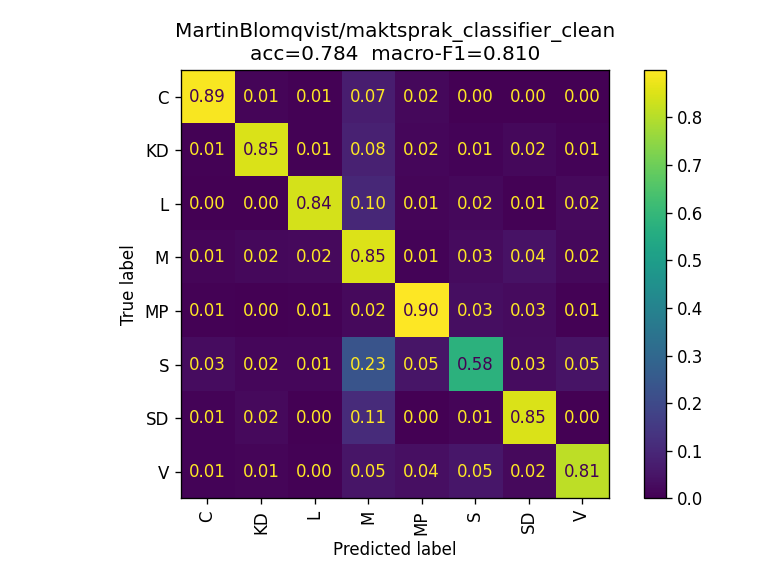

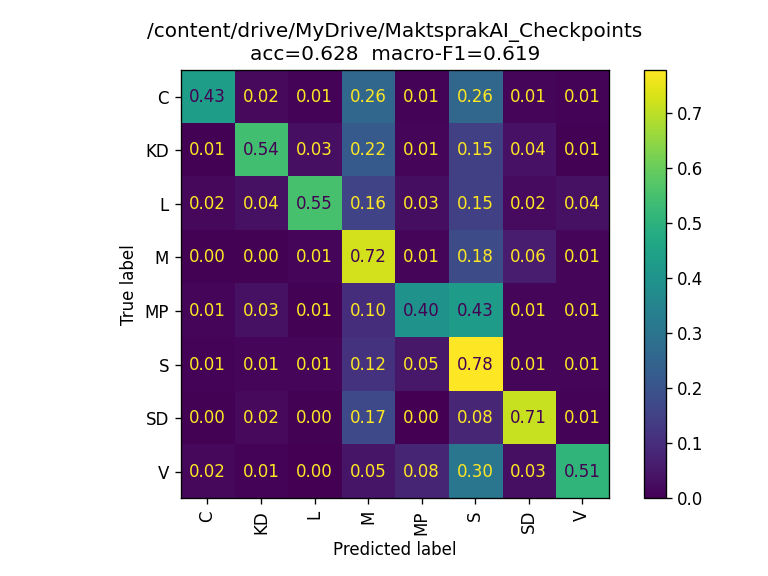

In [7]:
# 5. Benchmark the new model against the live one on the speaker-independent set
!python scripts/evaluate_model.py \
    --model MartinBlomqvist/maktsprak_classifier_clean \
    --model /content/drive/MyDrive/MaktsprakAI_Checkpoints \
    --val-speakers /content/drive/MyDrive/MaktsprakAI_Checkpoints/val_speakers.json \
    --limit 2000

import glob

from IPython.display import Image, display

for path in sorted(glob.glob("results/confusion_*.png")):
    display(Image(path))

In [8]:
# 6. If the new model wins the benchmark: push it to a NEW HF repo for A/B.
#    Promote to MartinBlomqvist/maktsprak_classifier_clean only once satisfied —
#    the live app loads that repo, so pushing there deploys immediately.
import os

from huggingface_hub import HfApi

api = HfApi(token=os.environ["HF_TOKEN"])
api.upload_folder(
    folder_path="/content/drive/MyDrive/MaktsprakAI_Checkpoints",
    repo_id="MartinBlomqvist/maktsprak_classifier_reindexed",
    repo_type="model",
    commit_message="Speaker-independent retrain on re-indexed data",
    ignore_patterns=["checkpoints/*", "*.pt"],  # HF export only, no raw checkpoints
)
print("Pushed to MartinBlomqvist/maktsprak_classifier_reindexed")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:100: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Pushed to MartinBlomqvist/maktsprak_classifier_reindexed
